In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
from typing import Union


import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
from typing import Union

def get_prices(
    ticker: Union[str, list[str]],
    start: Union[str, datetime, None] = None,
    end: Union[str, datetime, None] = None,
    lookback_days: int = 365,
    price_col: str = None,
    auto_adjust: bool = True,
) -> pd.DataFrame:
    """
    Fetch daily historical stock prices using yfinance.
    """
    if isinstance(end, str):
        end = datetime.strptime(end, "%Y-%m-%d")

    if isinstance(start, str):
        start = datetime.strptime(start, "%Y-%m-%d")

    if end is None:
        end = datetime.today()

    if start is None:
        start = end - timedelta(days=lookback_days) 

    # yfinance `end` is exclusive, so add one day to include the end date
    end_exclusive = end + timedelta(days=1)

    tickers = [ticker] if isinstance(ticker, str) else ticker

    raw_df: pd.DataFrame = yf.download(
        tickers=tickers,
        start=start.strftime("%Y-%m-%d"),
        end=end_exclusive.strftime("%Y-%m-%d"),
        auto_adjust=auto_adjust,
        progress=False,
        multi_level_index= True,
    )

    if raw_df.empty:
        raise ValueError(
            f"No data returned for {ticker} between {start.date()} and {end.date()}. "
            "Check that the ticker symbol is valid and the date range contains trading days."
        )
    
    # converts timezone data if exists
    raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz is not None else raw_df.index

    # Only narrow columns if caller explicitly requests a single column
    if price_col is not None:
        if len(tickers) == 1:
            raw_df= raw_df[[price_col]]
        else:
            raw_df = raw_df[price_col]

    return raw_df

In [13]:
from datetime import datetime
df = get_prices(ticker=["AAPL", "TSLA", "NVDA", "MSFT", "AMZN", "META", "GOOG"], start=datetime.today() - timedelta(days=365 * 10))
df.head()

Price           Close                                                         \
Ticker           AAPL       AMZN       GOOG        META       MSFT      NVDA   
Date                                                                           
2016-03-30  24.813202  29.934500  37.220917  113.806892  48.437889  0.875409   
2016-03-31  24.684103  29.681999  36.944191  113.211563  48.596275  0.872227   
2016-04-01  24.910591  29.924999  37.190163  115.156311  48.895428  0.884957   
2016-04-04  25.166510  29.659500  36.961052  111.673645  48.772247  0.876388   
2016-04-05  24.869829  29.306999  36.589607  111.346214  48.006748  0.875164   

Price                       High                        ...       Open  \
Ticker           TSLA       AAPL       AMZN       GOOG  ...       MSFT   
Date                                                    ...              
2016-03-30  15.126000  25.007975  30.162001  37.585424  ...  48.332303   
2016-03-31  15.318000  24.890201  30.037500  37.236787  ...  48.349907   
2016-04-01  15.839333  24.912856  29.951500  37.211487  ...  48.437885   
2016-04-04  16.466000  25.408844  29.975000  37.333494  ...  48.772247   
2016-04-05  17.031334  25.078193  29.673500  36.837572  ...  48.561076   

Price                               Volume                                \
Ticker          NVDA       TSLA       AAPL      AMZN      GOOG      META   
Date                                                                       
2016-03-30  0.869534  15.672667  182404400  77810000  35648000  33235200   
2016-03-31  0.879326  15.289333  103553600  53636000  34376000  21207500   
2016-04-01  0.866841  16.322001  103496000  58348000  31534000  24760500   
2016-04-04  0.892301  16.608000  149424800  49416000  22684000  48487900   
2016-04-05  0.868555  16.033333  106314800  46178000  22646000  22962400   

Price                                       
Ticker          MSFT       NVDA       TSLA  
Date                                        
2016-03-30  23008300  376700000   60495000  
2016-03-31  26360500  379884000  120193500  
2016-04-01  24399200  348292000  239962500  
2016-04-04  18928800  393940000  202129500  
2016-04-05  19272300  339568000  149230500  

[5 rows x 35 columns]

In [11]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close', 'GOOG'),
            ( 'Close', 'META'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'NVDA'),
            ( 'Close', 'TSLA'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High', 'GOOG'),
            (  'High', 'META'),
            (  'High', 'MSFT'),
            (  'High', 'NVDA'),
            (  'High', 'TSLA'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low', 'GOOG'),
            (   'Low', 'META'),
            (   'Low', 'MSFT'),
            (   'Low', 'NVDA'),
            (   'Low', 'TSLA'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open', 'GOOG'),
            (  'Open', 'META'),
            (  'Open', 'MSFT'),
            (  'Open', 'NVDA'),
            (  'Open', 'TSLA'),
            ('Volume', 'AAPL'),
            ('Volume', 'AMZN'),
            ('Volume', 'GOOG'),
        

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from arch import arch_model

def add_garch_feature(df: pd.DataFrame):
    """
        Garch Volatility Prediction
    """

    df = df.copy()

    returns = df["log_return"] * 100
    returns = returns.dropna()

    garch = arch_model(returns, vol='Garch', p=1, q=1)
    res = garch.fit(disp="off")

    garch_vol = res.conditional_volatility

    # Align index properly
    df["garch_vol"] = np.nan
    df.loc[garch_vol.index, "garch_vol"] = garch_vol.values

    df["garch_vol"] = df["garch_vol"].shift(1)

    return df

def compute_features(df: pd.DataFrame, price_col: str = "Close") -> pd.DataFrame:
    """
        From price series compute engineered features from OHLCV data.
    """

    df = df.copy()

    df["log_return"] = np.log(df[price_col] / df[price_col].shift(1))

    df["log_volume_change"] = np.log((df["Volume"] + 1) / (df["Volume"].shift(1) + 1)) # avoiding log 0 issues

    df["log_trading_range"] = np.log(df["High"]/df["Low"])
    df["close_open_return"] = np.log(df["Close"]/df["Open"])

    # Volatility features
    trading_days = 252
    df["realized_vol_5d"] = df["log_return"].rolling(5).std() * np.sqrt(trading_days)
    df["realized_vol_21d"] = df["log_return"].rolling(21).std() * np.sqrt(trading_days)
    df["realized_vol_63d"] = df["log_return"].rolling(63).std() * np.sqrt(trading_days)

    # Momentum Features
    df["ma_5"] = df["Close"].rolling(5).mean()
    df["ma_21"] = df["Close"].rolling(21).mean()
    df["ma_ratio"] = df["ma_5"] / df["ma_21"] #trend signal

    df["vol_change"] = df["realized_vol_21d"].pct_change()

    df = add_garch_feature(df)
    df["garch_vol"] = df["garch_vol"]


    df["daily_vol"] = df["log_return"].abs()

    df.dropna(inplace=True)

    return df

def build_sequences(
        df: pd.DataFrame,
        feature_cols: list[str],
        target_col: str,
        lookback: int = 63,
        horizons: list[int] = [30, 60, 90]

) -> tuple[np.ndarray, np.ndarray, StandardScaler, StandardScaler]:
    
    """
    Build (X, y) sequences for multi-horizon vol forecasting.

    X shape: (n_samples, lookback, n_features)
    y shape: (n_samples, len(horizons))  — one col per horizon

    Returns X, y, feature_scaler, target_scaler
    """
    
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    features = df[feature_cols].copy()

    # getting rid of outliers
    features = features.clip(
        lower=features.quantile(0.01),
        upper = features.quantile(0.99),
        axis=1
    )

    features_scaled = feature_scaler.fit_transform(features.values)

    raw_targets = df[target_col].values

    max_horizon = max(horizons)
    X, y = [], []

    for i in range(lookback, len(features_scaled) - max_horizon):

        start_X = i - lookback
        end_X = i

        past_window = features_scaled[start_X:end_X]

        future_targets = []

        for h in horizons:
            start_y = i
            end_y = i + h

            future_avg = np.mean(raw_targets[start_y:end_y]) 
            future_targets.append(float(future_avg))
        
        X.append(past_window)
        y.append(future_targets)

    
    X = np.array(X)
    y = np.array(y)

    y = target_scaler.fit_transform(y)

    
    return X, y, feature_scaler, target_scaler

In [4]:
def compute_features_multi(df: pd.DataFrame) -> pd.DataFrame:
    """ Compute's features for multiindex dataframes"""

    tickers = df.columns.get_level_values(1).unique()
    results = {}
    for ticker in tickers:
        ticker_df = df.xs(ticker, axis=1, level=1)
        results[ticker] = compute_features(ticker_df)
    return pd.concat(results, names=["ticker"])


In [5]:
computed_features_df = compute_features_multi(df)
print(computed_features_df.head())

Price                  Close       High        Low       Open     Volume  \
ticker Date                                                                
AAPL   2016-06-28  21.325357  21.341309  20.994962  21.168136  161779600   
       2016-06-29  21.509928  21.544107  21.334475  21.411948  146124000   
       2016-06-30  21.783358  21.822093  21.487141  21.519042  143345600   
       2016-07-01  21.849436  21.981595  21.721835  21.758292  104106000   
       2016-07-05  21.644363  21.737787  21.523598  21.735508  110820800   

Price              log_return  log_volume_change  log_trading_range  \
ticker Date                                                           
AAPL   2016-06-28    0.016700          -0.117543           0.016362   
       2016-06-29    0.008618          -0.101779           0.009778   
       2016-06-30    0.012632          -0.019197           0.015468   
       2016-07-01    0.003029          -0.319849           0.011888   
       2016-07-05   -0.009430           0

In [12]:
computed_features_df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'log_return',
       'log_volume_change', 'log_trading_range', 'close_open_return',
       'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d', 'ma_5',
       'ma_21', 'ma_ratio', 'vol_change', 'garch_vol', 'daily_vol'],
      dtype='str', name='Price')

In [6]:
computed_features_df.info()

<class 'pandas.DataFrame'>
MultiIndex: 17157 entries, ('AAPL', Timestamp('2016-06-28 00:00:00')) to ('TSLA', Timestamp('2026-03-27 00:00:00'))
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Close              17157 non-null  float64
 1   High               17157 non-null  float64
 2   Low                17157 non-null  float64
 3   Open               17157 non-null  float64
 4   Volume             17157 non-null  int64  
 5   log_return         17157 non-null  float64
 6   log_volume_change  17157 non-null  float64
 7   log_trading_range  17157 non-null  float64
 8   close_open_return  17157 non-null  float64
 9   realized_vol_5d    17157 non-null  float64
 10  realized_vol_21d   17157 non-null  float64
 11  realized_vol_63d   17157 non-null  float64
 12  ma_5               17157 non-null  float64
 13  ma_21              17157 non-null  float64
 14  ma_ratio           17157 non-null  float64
 15  vol

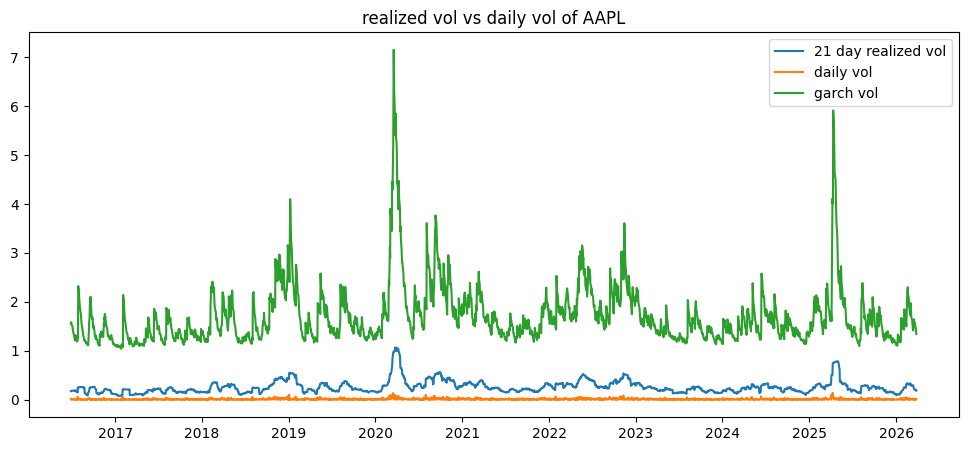

In [7]:
import matplotlib.pyplot as plt

ticker = "AAPL"
df_plot = computed_features_df.loc[ticker]

plt.figure(figsize=(12,5))
plt.plot(df_plot["realized_vol_21d"], label="21 day realized vol")
plt.plot(df_plot["daily_vol"], label= "daily vol")
plt.plot(df_plot["garch_vol"], label = "garch vol")
plt.legend()
plt.title(f"realized vol vs daily vol of {ticker}")
plt.show()